## HW 01

1. 강의 게시판의 a.wav 파일을 읽는다.
2. w0, w1, w2가 모두 1/3인 3-tap FIR 필터로 전체 파일을 필터링한다.
3. 필터링 결과를 a_out.wav로 저장한다.
4. a.wav와 a_out.wav를 들어 보고 비교한다.
5. a_out.wav와 비교 보고서를 이메일로 제출한다.

due date: 9/14 MON

### 실험 코드

#### 환경 체크

In [126]:
import sys

print(sys.executable)
print("Python version:", sys.version)

/Users/yejin/Development/Yejin-02/26-Fall-Adap/.venv/bin/python
Python version: 3.9.6 (default, Oct 17 2025, 17:15:53) 
[Clang 17.0.0 (clang-1700.4.4.1)]


#### 과제 음성 청취

In [127]:
from pathlib import Path

import soundfile as sf
from IPython.display import Audio, display

input_path = Path("a.wav")

display(Audio(filename=input_path))

data, samplerate = sf.read(input_path)

print(f"Data shape: {data.shape}")
print(f"Sample rate: {samplerate} Hz")
print(f"Duration: {data.shape[0] / samplerate:.2f} seconds")
print(f"Data type: {data.dtype}")

Data shape: (18800,)
Sample rate: 8000 Hz
Duration: 2.35 seconds
Data type: float64


남성 화자의 2.35초 / 1 채널 / sr=8kHz / float64 타입 영어 발화 음성

#### 필터 적용

In [128]:
import numpy as np

tap_line = np.array([1/3, 1/3, 1/3], dtype=np.float64)

output_data = np.convolve(data, tap_line, mode = "full")

print(f"Output data shape: {output_data.shape}")
print(f"Length difference: {output_data.shape[0] - data.shape[0]} samples")
print(f"Duration difference: {(output_data.shape[0] - data.shape[0]) / samplerate * 1000:.2f} ms")

Output data shape: (18802,)
Length difference: 2 samples
Duration difference: 0.25 ms


- 3-tap 필터는 LTI 시스템 중에서도 FIR 시스템
- 따라서 numpy의 convolve 연산을 통해 입력 신호와 시스템 IR의 linear convolution summation을 수행하여 출력 신호를 계산
- 길이가 3인 FIR 필터이므로 원 신호보다 두 샘플이 늘어나 18802개 샘플의 출력 신호가 생성 (18800 + 3 - 1)
- 시간으로는 0.25ms 차이로 매우 근소한 차이

#### 출력 음성 청취

In [129]:
sf.write("a_out.wav", output_data, samplerate)

display(Audio(filename=input_path))
display(Audio(filename="a_out.wav"))

출력 신호를 wav 파일로 저장한 후 입력 신호와 비교하여 들어 본 결과, 입력 신호보다 뭉툭하게 들린다는 것을 알 수 있었음. 이는 3-tap FIR이 moving average filter로서 low-pass filter의 역할을 하기 때문임. 3-tap 필터이기 때문에 ideal low-pass filter만큼 고주파 성분을 확실하게 cut-off하지는 못하지만, 청취 시 확실히 차이를 인지할 수 있을 정도로 변화가 일어남.

### 분석

#### 3-tap filter Frequency Response

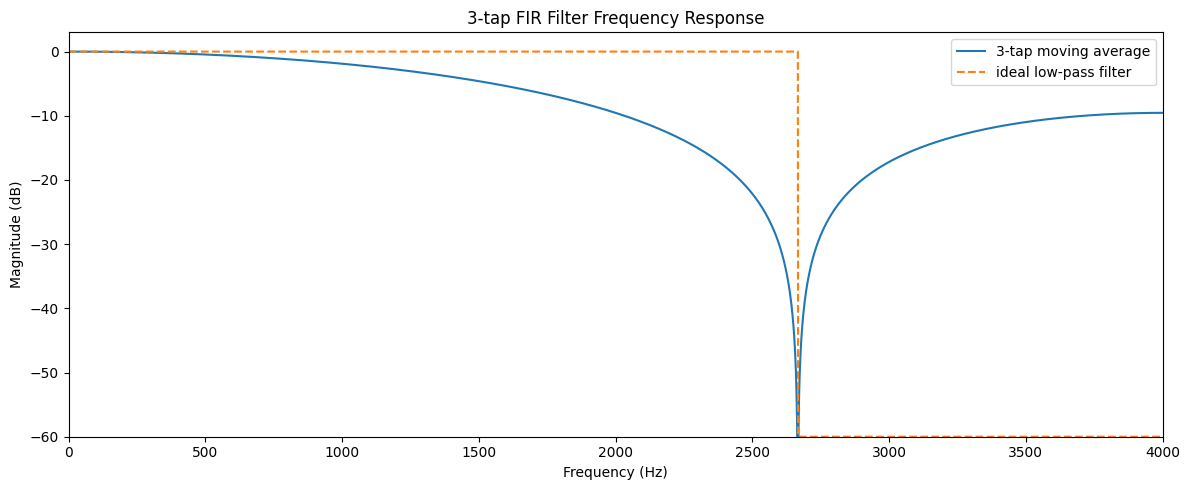

In [130]:
import matplotlib.pyplot as plt

fs = samplerate

# 겹치는 정보 없이 0 ~ Nyquist frequency만 표시
w = np.linspace(0, np.pi, 4096)
freq = w / (2 * np.pi) * fs

# 3-tap moving average filter의 frequency response
H = (1 + np.exp(-1j * w) + np.exp(-1j * 2 * w)) / 3
H_db = 20 * np.log10(np.maximum(np.abs(H), 1e-12))

# 첫 번째 영점 주파수를 기준으로 한 ideal low-pass reference
fc = fs / 3
ideal_db = np.where(freq <= fc, 0.0, -60.0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(freq, H_db, label="3-tap moving average")
ax.plot(freq, ideal_db, linestyle="--", label="ideal low-pass filter")

ax.set_xlim(0, fs / 2)
ax.set_ylim(-60, 3)
ax.set_xticks(np.arange(0, fs / 2 + 1, 500))
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("3-tap FIR Filter Frequency Response")

ax.legend()
plt.tight_layout()
plt.show()

- 3-tap FIR 필터의 주파수 응답을 계산 후 dB 스케일로 나타내면(파란색 실선) 0 Hz에서 0 dB로 시작하여 약 2666 Hz까지 점차 감소
- 이는 저주파 성분에서 중~고주파 성분으로 갈 수록 서서히 감쇠가 일어나는 형태로 low-pass의 특성이라고 할 수 있음
- 그러나 이를 cutoff frequency로 가지는 ideal low-pass filter(주황색 점선)와 비교하면 cutoff 이후를 완전히 막는 것이 아니라 sidelobe가 나타나는 것을 볼 수 있으며 고주파 성분($\pi$, 4000 Hz)이 약 -10 dB 정도로 남는 것을 확인
- 따라서 이는 non-ideal low-pass filter

#### 주파수 도메인 분석

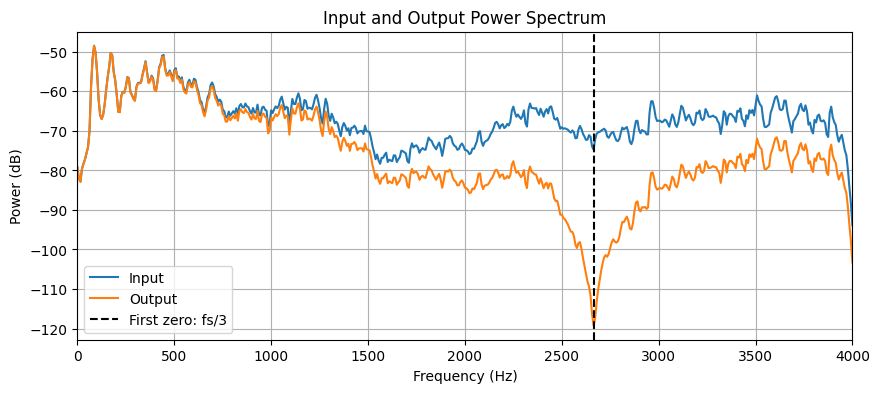

In [131]:
from scipy.signal import welch

f_in, p_in = welch(data, samplerate, nperseg=1024)
f_out, p_out = welch(output_data, samplerate, nperseg=1024)

plt.figure(figsize=(10, 4))
plt.plot(f_in, 10 * np.log10(p_in + 1e-12), label="Input")
plt.plot(f_out, 10 * np.log10(p_out + 1e-12), label="Output")
plt.axvline(samplerate / 3, color="k", linestyle="--",
            label="First zero: fs/3")
plt.xlim(0, samplerate / 2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.title("Input and Output Power Spectrum")
plt.grid()
plt.legend()
plt.show()

- 입력 신호와 출력 신호를 power spectrum으로 비교
- 저주파 영역에서는 비슷한 형태
- 주파수가 증가할수록 출력 신호의 power가 점점 낮아져 위에서 확인한 첫 번째 영점 주파수 근처에서 크게 차이가 나는 것을 확인
- 또, 그 이후의 주파수 영역에서도 입력 신호보다 낮은 power가 나타남
- 즉, 위에서 이론적으로 확인한 필터의 주파수 응답에 대응 되는 출력 신호의 특성을 주파수 도메인에서 확인

#### 시간-주파수 도메인 분석

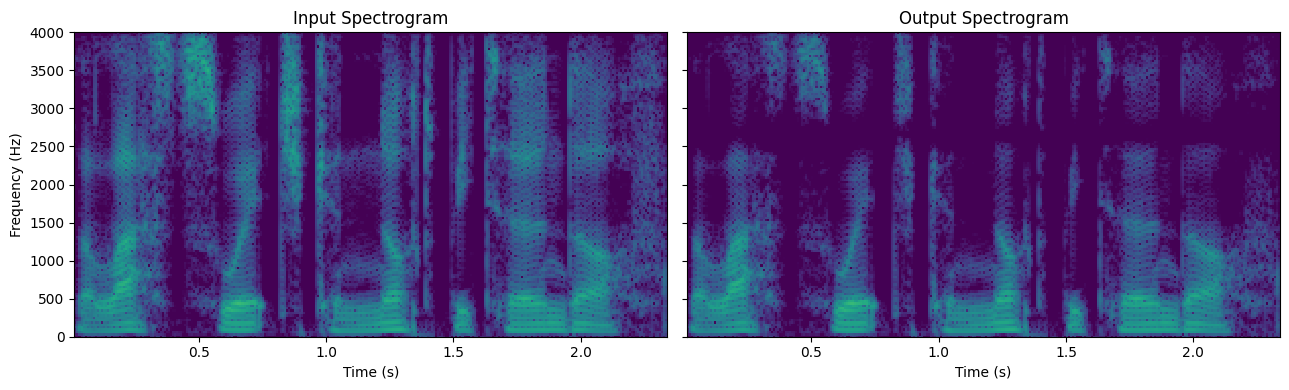

In [132]:
from scipy.signal import stft

f1, t1, z1 = stft(
    data, fs=samplerate,
    window="hann", nperseg=256,
    noverlap=192, boundary=None
)

f2, t2, z2 = stft(
    output_data, fs=samplerate,
    window="hann", nperseg=256,
    noverlap=192, boundary=None
)

db1 = 20 * np.log10(np.maximum(np.abs(z1), 1e-6))
db2 = 20 * np.log10(np.maximum(np.abs(z2), 1e-6))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

axes[0].pcolormesh(t1, f1, db1, shading="auto", vmin=-80, vmax=0)
axes[0].set_title("Input Spectrogram")

axes[1].pcolormesh(t2, f2, db2, shading="auto", vmin=-80, vmax=0)
axes[1].set_title("Output Spectrogram")

for ax in axes:
    ax.set_ylim(0, samplerate / 2)
    ax.set_xlabel("Time (s)")
    ax.grid(False)

axes[0].set_ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

- 시간-주파수 도메인에서도 입출력 신호 변화를 확인
- 출력 신호의 spectrogram에서 전체 duration에 걸쳐 2666 Hz 부근에서 큰 감쇠가 일어났으며, 이외에도 고주파 영역이 전체적으로 어둡게 나타남을 확인
- 이는 앞선 두 개의 분석과 일치하는 결과